Enter number of processes: 4

Randomly generated Arrival Times (AT) and Burst Times (BT):
P1 -> AT: 3, BT: 6
P2 -> AT: 1, BT: 1
P3 -> AT: 5, BT: 6
P4 -> AT: 2, BT: 4

PID  AT  BT  WT  TAT
P2   1   1   0   1
P4   2   4   0   4
P1   3   6   3   9
P3   5   6   7   13

Average Waiting Time = 2.5
Average Turnaround Time = 6.75


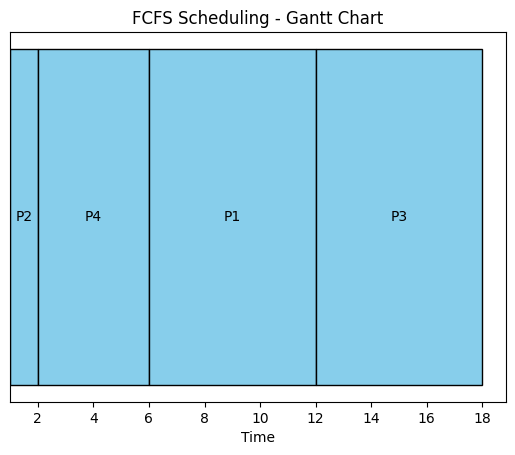

In [ ]:
#fcfs
import random
import matplotlib.pyplot as plt

# Take number of processes from user
n = int(input("Enter number of processes: "))

processes = []

# Generate random arrival and burst times
print("\nRandomly generated Arrival Times (AT) and Burst Times (BT):")
for i in range(n):
    at = random.randint(0, 5)   # Arrival time 0–5
    bt = random.randint(1, 6)   # Burst time 1–6
    processes.append([f"P{i+1}", at, bt])
    print(f"P{i+1} -> AT: {at}, BT: {bt}")

# Sort processes by arrival time (FCFS)
processes.sort(key=lambda x: x[1])

current_time = 0
timeline = []

total_wt = 0
total_tat = 0

print("\nPID  AT  BT  WT  TAT")
for p in processes:
    pid, at, bt = p

    if current_time < at:
        current_time = at   # CPU idle

    wt = current_time - at
    tat = wt + bt

    total_wt += wt
    total_tat += tat

    print(f"{pid}   {at}   {bt}   {wt}   {tat}")

    timeline.append((pid, current_time, bt))
    current_time += bt

print("\nAverage Waiting Time =", round(total_wt / n, 2))
print("Average Turnaround Time =", round(total_tat / n, 2))

# -------- Gantt Chart --------
fig, ax = plt.subplots()

for task in timeline:
    ax.barh(1, task[2], left=task[1], color='skyblue', edgecolor='black')
    ax.text(task[1] + task[2]/2, 1, task[0],
            ha='center', va='center', color='black', fontsize=10)

ax.set_xlabel("Time")
ax.set_yticks([])
ax.set_title("FCFS Scheduling - Gantt Chart")
plt.show()


Enter number of processes: 5

Randomly generated Arrival Times (AT) and Burst Times (BT):
P1 -> AT: 2, BT: 2
P2 -> AT: 4, BT: 3
P3 -> AT: 4, BT: 6
P4 -> AT: 5, BT: 4
P5 -> AT: 2, BT: 3

PID  AT  BT  WT  TAT
P1   2   2   0   2
P5   2   3   2   5
P2   4   3   3   6
P3   4   6   6   12
P4   5   4   11   15

Average Waiting Time = 4.4
Average Turnaround Time = 8.0


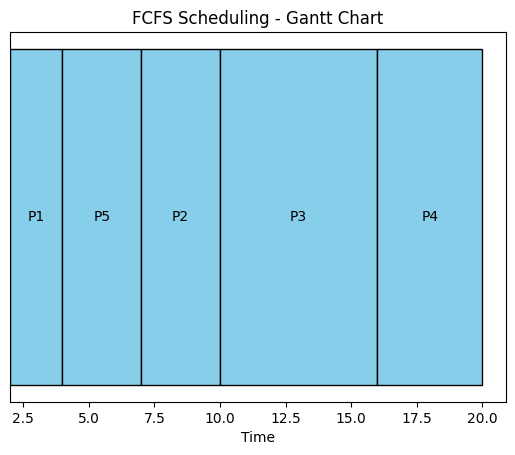

In [ ]:
#fcfs
import random
import matplotlib.pyplot as plt

# Take number of processes from user
n = int(input("Enter number of processes: "))

processes = []

# Generate random arrival and burst times
print("\nRandomly generated Arrival Times (AT) and Burst Times (BT):")
for i in range(n):
    at = random.randint(0, 5)   # Arrival time 0–5
    bt = random.randint(1, 6)   # Burst time 1–6
    processes.append([f"P{i+1}", at, bt])
    print(f"P{i+1} -> AT: {at}, BT: {bt}")

# Sort processes by arrival time (FCFS)
processes.sort(key=lambda x: x[1])

current_time = 0
timeline = []

total_wt = 0
total_tat = 0

print("\nPID  AT  BT  WT  TAT")
for p in processes:
    pid, at, bt = p

    if current_time < at:
        current_time = at   # CPU idle

    wt = current_time - at
    tat = wt + bt

    total_wt += wt
    total_tat += tat

    print(f"{pid}   {at}   {bt}   {wt}   {tat}")

    timeline.append((pid, current_time, bt))
    current_time += bt

print("\nAverage Waiting Time =", round(total_wt / n, 2))
print("Average Turnaround Time =", round(total_tat / n, 2))

# -------- Gantt Chart --------
fig, ax = plt.subplots()

for task in timeline:
    ax.barh(1, task[2], left=task[1], color='skyblue', edgecolor='black')
    ax.text(task[1] + task[2]/2, 1, task[0],
            ha='center', va='center', color='black', fontsize=10)

ax.set_xlabel("Time")
ax.set_yticks([])
ax.set_title("FCFS Scheduling - Gantt Chart")
plt.show()


Enter number of processes: 5

Randomly generated Arrival & Burst Times:
P1 -> AT: 0, BT: 3
P2 -> AT: 5, BT: 6
P3 -> AT: 0, BT: 4
P4 -> AT: 3, BT: 6
P5 -> AT: 2, BT: 3

PID  AT  BT  WT  TAT
P1   0   3   0   3
P2   5   6   11   17
P3   0   4   6   10
P4   3   6   7   13
P5   2   3   1   4

Average Waiting Time = 5.0
Average Turnaround Time = 9.4


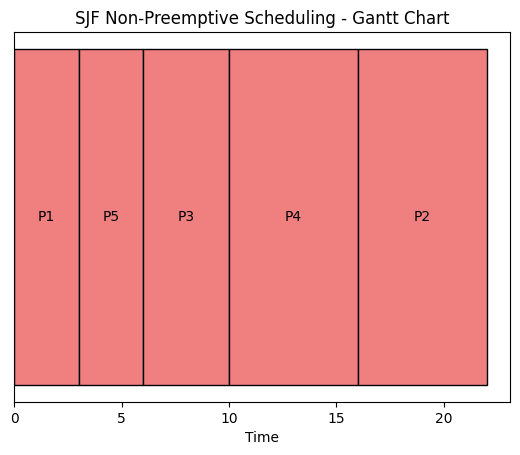

In [ ]:
#sjf - non preemptive

import random
import matplotlib.pyplot as plt

# Number of processes
n = int(input("Enter number of processes: "))

processes = []

# Random Arrival Time (0-5) and Burst Time (1-6)
print("\nRandomly generated Arrival & Burst Times:")
for i in range(n):
    at = random.randint(0, 5)
    bt = random.randint(1, 6)
    processes.append([f"P{i+1}", at, bt])
    print(f"P{i+1} -> AT: {at}, BT: {bt}")

# SJF Non-preemptive logic
completed = 0
current_time = 0
visited = [False]*n
timeline = []

wt_list = [0]*n
tat_list = [0]*n

while completed < n:
    # Find process with minimum BT among arrived & not completed
    idx = -1
    min_bt = float('inf')
    for i in range(n):
        if processes[i][1] <= current_time and not visited[i]:
            if processes[i][2] < min_bt:
                min_bt = processes[i][2]
                idx = i
            elif processes[i][2] == min_bt:
                if processes[i][1] < processes[idx][1]:  # tie-break by arrival
                    idx = i
    if idx == -1:
        current_time += 1  # CPU idle
    else:
        pid, at, bt = processes[idx]
        wt = current_time - at
        tat = wt + bt
        wt_list[idx] = wt
        tat_list[idx] = tat
        timeline.append((pid, current_time, bt))
        current_time += bt
        visited[idx] = True
        completed += 1

# Print results
print("\nPID  AT  BT  WT  TAT")
for i in range(n):
    pid, at, bt = processes[i]
    print(f"{pid}   {at}   {bt}   {wt_list[i]}   {tat_list[i]}")

print("\nAverage Waiting Time =", round(sum(wt_list)/n, 2))
print("Average Turnaround Time =", round(sum(tat_list)/n, 2))

# --- Gantt Chart ---
fig, ax = plt.subplots()
for task in timeline:
    ax.barh(1, task[2], left=task[1], color='lightcoral', edgecolor='black')
    ax.text(task[1] + task[2]/2, 1, task[0], ha='center', va='center', color='black', fontsize=10)

ax.set_xlabel("Time")
ax.set_yticks([])
ax.set_title("SJF Non-Preemptive Scheduling - Gantt Chart")
plt.show()


Enter number of processes: 5

Randomly generated Arrival & Burst Times:
P1 -> AT: 2, BT: 1
P2 -> AT: 0, BT: 2
P3 -> AT: 3, BT: 1
P4 -> AT: 0, BT: 3
P5 -> AT: 5, BT: 6

PID  AT  BT  WT  TAT
P1   2   1   0   1
P2   0   2   0   2
P3   3   1   0   1
P4   0   3   4   7
P5   5   6   2   8

Average Waiting Time = 1.2
Average Turnaround Time = 3.8


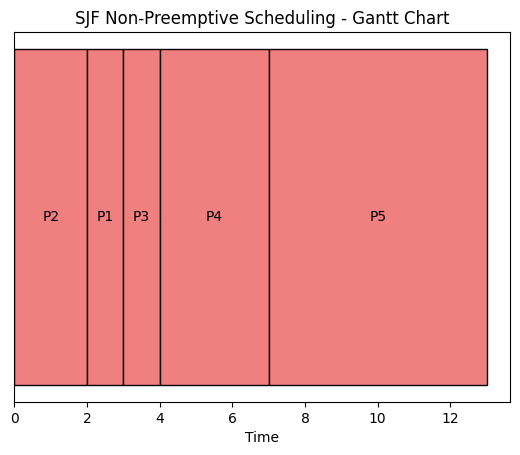

In [ ]:
#sjf - non preemptive

import random
import matplotlib.pyplot as plt

# Number of processes
n = int(input("Enter number of processes: "))

processes = []

# Random Arrival Time (0-5) and Burst Time (1-6)
print("\nRandomly generated Arrival & Burst Times:")
for i in range(n):
    at = random.randint(0, 5)
    bt = random.randint(1, 6)
    processes.append([f"P{i+1}", at, bt])
    print(f"P{i+1} -> AT: {at}, BT: {bt}")

# SJF Non-preemptive logic
completed = 0
current_time = 0
visited = [False]*n
timeline = []

wt_list = [0]*n
tat_list = [0]*n

while completed < n:
    # Find process with minimum BT among arrived & not completed
    idx = -1
    min_bt = float('inf')
    for i in range(n):
        if processes[i][1] <= current_time and not visited[i]:
            if processes[i][2] < min_bt:
                min_bt = processes[i][2]
                idx = i
            elif processes[i][2] == min_bt:
                if processes[i][1] < processes[idx][1]:  # tie-break by arrival
                    idx = i
    if idx == -1:
        current_time += 1  # CPU idle
    else:
        pid, at, bt = processes[idx]
        wt = current_time - at
        tat = wt + bt
        wt_list[idx] = wt
        tat_list[idx] = tat
        timeline.append((pid, current_time, bt))
        current_time += bt
        visited[idx] = True
        completed += 1

# Print results
print("\nPID  AT  BT  WT  TAT")
for i in range(n):
    pid, at, bt = processes[i]
    print(f"{pid}   {at}   {bt}   {wt_list[i]}   {tat_list[i]}")

print("\nAverage Waiting Time =", round(sum(wt_list)/n, 2))
print("Average Turnaround Time =", round(sum(tat_list)/n, 2))

# --- Gantt Chart ---
fig, ax = plt.subplots()
for task in timeline:
    ax.barh(1, task[2], left=task[1], color='lightcoral', edgecolor='black')
    ax.text(task[1] + task[2]/2, 1, task[0], ha='center', va='center', color='black', fontsize=10)

ax.set_xlabel("Time")
ax.set_yticks([])
ax.set_title("SJF Non-Preemptive Scheduling - Gantt Chart")
plt.show()


Enter number of processes: 5

Randomly generated Arrival & Burst Times:
P1 -> AT: 4, BT: 1
P2 -> AT: 3, BT: 2
P3 -> AT: 4, BT: 5
P4 -> AT: 0, BT: 6
P5 -> AT: 0, BT: 1

PID  AT  BT  WT  TAT
P1   4   1   1   2
P2   3   2   0   2
P3   4   5   6   11
P4   0   6   4   10
P5   0   1   0   1

Average Waiting Time = 2.2
Average Turnaround Time = 5.2


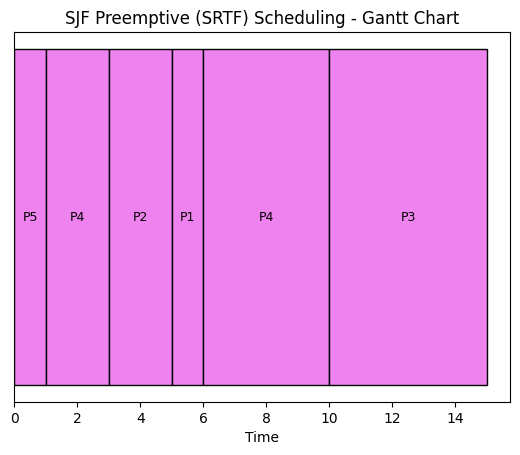

In [ ]:
#sjf - preemptive
import random
import matplotlib.pyplot as plt

# Number of processes
n = int(input("Enter number of processes: "))

processes = []

# Random Arrival Time (0-5) and Burst Time (1-6)
print("\nRandomly generated Arrival & Burst Times:")
for i in range(n):
    at = random.randint(0, 5)
    bt = random.randint(1, 6)
    processes.append([f"P{i+1}", at, bt])
    print(f"P{i+1} -> AT: {at}, BT: {bt}")

# Remaining burst time
remaining_bt = [p[2] for p in processes]

completed = 0
current_time = 0
prev_process = None
timeline = []

wt_list = [0]*n
tat_list = [0]*n
completion_time = [0]*n

while completed < n:
    idx = -1
    min_rt = float('inf')

    # Select process with minimum remaining time among arrived ones
    for i in range(n):
        if processes[i][1] <= current_time and remaining_bt[i] > 0:
            if remaining_bt[i] < min_rt:
                min_rt = remaining_bt[i]
                idx = i
            elif remaining_bt[i] == min_rt:
                if processes[i][1] < processes[idx][1]:
                    idx = i

    if idx == -1:
        current_time += 1  # CPU idle
        continue

    pid = processes[idx][0]

    # If CPU switches process, close previous slot
    if prev_process != pid:
        timeline.append([pid, current_time, 1])
    else:
        timeline[-1][2] += 1

    remaining_bt[idx] -= 1
    current_time += 1
    prev_process = pid

    if remaining_bt[idx] == 0:
        completed += 1
        completion_time[idx] = current_time
        tat_list[idx] = completion_time[idx] - processes[idx][1]
        wt_list[idx] = tat_list[idx] - processes[idx][2]

# Print results
print("\nPID  AT  BT  WT  TAT")
for i in range(n):
    pid, at, bt = processes[i]
    print(f"{pid}   {at}   {bt}   {wt_list[i]}   {tat_list[i]}")

print("\nAverage Waiting Time =", round(sum(wt_list)/n, 2))
print("Average Turnaround Time =", round(sum(tat_list)/n, 2))

# --- Gantt Chart ---
fig, ax = plt.subplots()
for task in timeline:
    ax.barh(1, task[2], left=task[1], color='violet', edgecolor='black')
    ax.text(task[1] + task[2]/2, 1, task[0], ha='center', va='center', fontsize=9)

ax.set_xlabel("Time")
ax.set_yticks([])
ax.set_title("SJF Preemptive (SRTF) Scheduling - Gantt Chart")
plt.show()


Enter number of processes: 5

Enter Arrival Time (AT) and Burst Time (BT) for each process:
Enter Arrival Time for P1: 2
Enter Burst Time for P1: 1
Enter Arrival Time for P2: 0
Enter Burst Time for P2: 1
Enter Arrival Time for P3: 0
Enter Burst Time for P3: 4
Enter Arrival Time for P4: 5
Enter Burst Time for P4: 2
Enter Arrival Time for P5: 0
Enter Burst Time for P5: 3

PID  AT  BT  WT  TAT
P2   0   1   0   1
P3   0   4   1   5
P5   0   3   5   8
P1   2   1   6   7
P4   5   2   4   6

Average Waiting Time = 3.2
Average Turnaround Time = 5.4


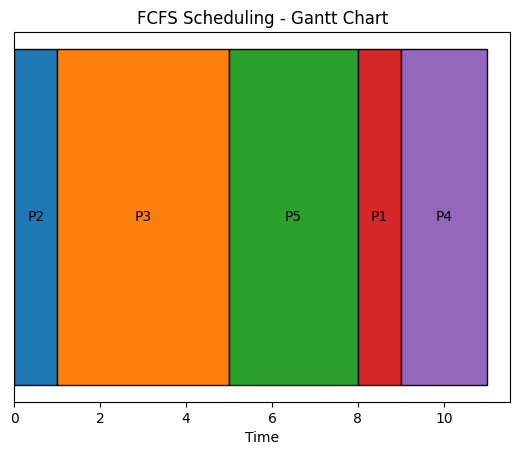

In [ ]:
# FCFS Scheduling with user input
import matplotlib.pyplot as plt

# Take number of processes from user
n = int(input("Enter number of processes: "))

processes = []

# Take Arrival Time and Burst Time from user
print("\nEnter Arrival Time (AT) and Burst Time (BT) for each process:")
for i in range(n):
    at = int(input(f"Enter Arrival Time for P{i+1}: "))
    bt = int(input(f"Enter Burst Time for P{i+1}: "))
    processes.append([f"P{i+1}", at, bt])

# Sort processes by arrival time (FCFS rule)
processes.sort(key=lambda x: x[1])

current_time = 0
timeline = []

total_wt = 0
total_tat = 0

print("\nPID  AT  BT  WT  TAT")
for p in processes:
    pid, at, bt = p

    # If CPU is idle
    if current_time < at:
        current_time = at

    wt = current_time - at
    tat = wt + bt

    total_wt += wt
    total_tat += tat

    print(f"{pid}   {at}   {bt}   {wt}   {tat}")

    timeline.append((pid, current_time, bt))
    current_time += bt

print("\nAverage Waiting Time =", round(total_wt / n, 2))
print("Average Turnaround Time =", round(total_tat / n, 2))

# -------- Gantt Chart --------
fig, ax = plt.subplots()

for task in timeline:
    ax.barh(1, task[2], left=task[1], edgecolor='black')
    ax.text(task[1] + task[2]/2, 1, task[0],
            ha='center', va='center', fontsize=10)

ax.set_xlabel("Time")
ax.set_yticks([])
ax.set_title("FCFS Scheduling - Gantt Chart")
plt.show()


Enter number of processes: 5

Enter Arrival Time (AT) and Burst Time (BT) for each process:
Enter Arrival Time for P1: 0
Enter Burst Time for P1: 5
Enter Arrival Time for P2: 5
Enter Burst Time for P2: 6
Enter Arrival Time for P3: 5
Enter Burst Time for P3: 3
Enter Arrival Time for P4: 2
Enter Burst Time for P4: 6
Enter Arrival Time for P5: 0
Enter Burst Time for P5: 5

PID  AT  BT  WT  TAT
P1   0   5   0   5
P2   5   6   14   20
P3   5   3   0   3
P4   2   6   11   17
P5   0   5   8   13

Average Waiting Time = 6.6
Average Turnaround Time = 11.6


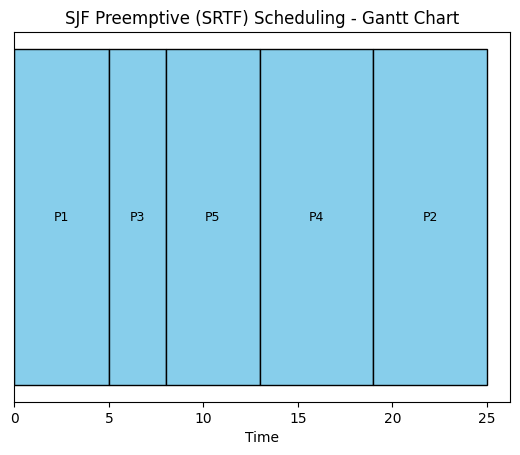

In [ ]:
# SJF Preemptive (SRTF) with user input
import matplotlib.pyplot as plt

# Number of processes
n = int(input("Enter number of processes: "))

processes = []

# Take Arrival Time and Burst Time from user
print("\nEnter Arrival Time (AT) and Burst Time (BT) for each process:")
for i in range(n):
    at = int(input(f"Enter Arrival Time for P{i+1}: "))
    bt = int(input(f"Enter Burst Time for P{i+1}: "))
    processes.append([f"P{i+1}", at, bt])

# Remaining burst time
remaining_bt = [p[2] for p in processes]

completed = 0
current_time = 0
prev_process = None
timeline = []

wt_list = [0] * n
tat_list = [0] * n
completion_time = [0] * n

while completed < n:
    idx = -1
    min_rt = float('inf')

    # Select process with minimum remaining time among arrived ones
    for i in range(n):
        if processes[i][1] <= current_time and remaining_bt[i] > 0:
            if remaining_bt[i] < min_rt:
                min_rt = remaining_bt[i]
                idx = i
            elif remaining_bt[i] == min_rt:
                if processes[i][1] < processes[idx][1]:
                    idx = i

    # If no process has arrived, CPU is idle
    if idx == -1:
        current_time += 1
        continue

    pid = processes[idx][0]

    # If CPU switches process, start new Gantt slot
    if prev_process != pid:
        timeline.append([pid, current_time, 1])
    else:
        timeline[-1][2] += 1

    remaining_bt[idx] -= 1
    current_time += 1
    prev_process = pid

    # If process finished
    if remaining_bt[idx] == 0:
        completed += 1
        completion_time[idx] = current_time
        tat_list[idx] = completion_time[idx] - processes[idx][1]
        wt_list[idx] = tat_list[idx] - processes[idx][2]

# Print results
print("\nPID  AT  BT  WT  TAT")
for i in range(n):
    pid, at, bt = processes[i]
    print(f"{pid}   {at}   {bt}   {wt_list[i]}   {tat_list[i]}")

print("\nAverage Waiting Time =", round(sum(wt_list) / n, 2))
print("Average Turnaround Time =", round(sum(tat_list) / n, 2))

# --- Gantt Chart ---
fig, ax = plt.subplots()

for task in timeline:
    ax.barh(1, task[2], left=task[1], color='skyblue', edgecolor='black')
    ax.text(task[1] + task[2] / 2, 1, task[0],
            ha='center', va='center', fontsize=9)

ax.set_xlabel("Time")
ax.set_yticks([])
ax.set_title("SJF Preemptive (SRTF) Scheduling - Gantt Chart")
plt.show()
